In [1]:
import sys
sys.path.append('/n/home02/pbb/scripts/halo-metadata-server/')
from Classes import Project
import pandas as pd
from pathlib import Path
import ipywidgets
import glob
import matplotlib.pyplot as plt
import numpy as np

In [2]:
pdir = '/n/davies_lab/Lab/data/processed/Africa/Kruger/2020/2020_01-02/20200116_NkuluEP'

# New project, merge tiles
proj = Project(pdir, loadfromjson=True)

In [3]:
proj.Trajectory.getUTMtraj()
proj.Trajectory.alltrajs.keys()

dict_keys(['time', 'latitude', 'longitude', 'altitude', 'x_vel', 'y_vel', 'z_vel', 'roll', 'pitch', 'platform_heading', 'wander_angle', 'x_acceleration', 'y_acceleration', 'z_acceleration', 'x_angular_rate', 'y_angular_rate', 'z_angular'])

In [44]:
UTMTraj = pd.DataFrame({'GPSTime':proj.Trajectory.alltrajs['time'],
                        'Lat':proj.Trajectory.alltrajs['latitude'],
                        'Lon':proj.Trajectory.alltrajs['longitude'],
                        'Easting':proj.Trajectory.alltrajs_utm['easting'],
                        'Northing':proj.Trajectory.alltrajs_utm['northing'],
                        'Altitude':proj.Trajectory.alltrajs['altitude'],
                        'Roll':proj.Trajectory.alltrajs['roll'],
                        'Pitch':proj.Trajectory.alltrajs['pitch'],
                        'Heading':proj.Trajectory.alltrajs['platform_heading']})

# For some reason, at Nkuhlu, some (840) of the trajectory values are really weird.
# If you cut them, looks normal. Most likely there's an errant sbet file causing this. 
# sum(UTMTraj.Lat >-5) # this = 840
# This should fix it 
UTMTraj = UTMTraj.loc[UTMTraj.Lat < -5]

UTMTraj.sort_values(by='GPSTime', ascending=True, inplace=True, ignore_index=True)


UTMTraj.to_csv(f'{proj.projdir}/docs/{proj.date}_{proj.projstr}_Trajectory_EPSG{proj.epsg}.csv')

UTMTraj.head()

,GPSTime,Lat,Lon,Easting,Northing,Altitude,Roll,Pitch,Heading
0,366985.247157,-24.994273,31.771431,3.483427e+06,-3.099953e+06,222.535126,-0.038321,-0.067664,-1.533775
1,366985.327157,-24.994273,31.771432,3.483427e+06,-3.099953e+06,222.534698,-0.038327,-0.067769,-1.533802
2,366985.407157,-24.994273,31.771432,3.483427e+06,-3.099953e+06,222.534225,-0.038319,-0.067754,-1.533835
3,366985.487157,-24.994273,31.771432,3.483427e+06,-3.099953e+06,222.533752,-0.038303,-0.067782,-1.533802
4,366985.567157,-24.994273,31.771432,3.483427e+06,-3.099953e+06,222.533325,-0.038306,-0.067671,-1.533830


In [277]:
# find a bunch of candidates for image timing files
imgtimefiles = list(glob.glob(f'{proj.projdir}/**/*.txt', recursive=True))

# Use a widget to select the corret image file 
select = ipywidgets.Dropdown(
        options=imgtimefiles,
        value=None,
        description='Image Time File:',
        layout={'width': 'max-content'},
        disabled=False)
select

Dropdown(description='Image Time File:', layout=Layout(width='max-content'), options=('/n/davies_lab/Lab/data/…

In [278]:
itf

'/n/davies_lab/Lab/data/processed/Africa/Kruger/2020/2020_01-02/20200116_NkuluEP/Terrasolid/Terraphoto/thermal/cam1_multiband_allflights_NewImgTiming.txt'

In [177]:
itf = select.value

it = pd.read_csv(itf, sep=' ', header=None,
                 names=['GPSTime', 'Imagef'])
it.head()

,GPSTime,Imagef
0,367614.238,Flight1_cam1-000-000000-0
1,367617.308,Flight1_cam1-000-000001-0
2,367620.244,Flight1_cam1-000-000002-0
3,367623.180,Flight1_cam1-000-000003-0
4,367626.250,Flight1_cam1-000-000004-0


In [178]:
# Find indices of everywhere there's an image (approximate time location)
# idx = [np.argmin(np.abs(UTMTraj.GPSTime - t)) for t in it.GPSTime]

# get position (easting, northing, alt.) of each image, by linear interpolation
North_interp = []
East_interp = [] 
Alt_interp = []
for t in it.GPSTime:
    
    # Index of time in trajectory closest to the iamge capture
    idx = np.argmin(np.abs(UTMTraj.GPSTime - t))
    
    # Get the interpolated position
    # Using the index 
    North_interp.append(np.interp(t,
                                 UTMTraj.GPSTime[(idx-1):idx:(idx+1)],
                                 UTMTraj.Northing[(idx-1):idx:(idx+1)]))
    
    East_interp.append(np.interp(t,
                             UTMTraj.GPSTime[(idx-1):idx:(idx+1)],
                             UTMTraj.Easting[(idx-1):idx:(idx+1)])) 
        
    Alt_interp.append(np.interp(t,
                         UTMTraj.GPSTime[(idx-1):idx:(idx+1)],
                         UTMTraj.Altitude[(idx-1):idx:(idx+1)]))
    

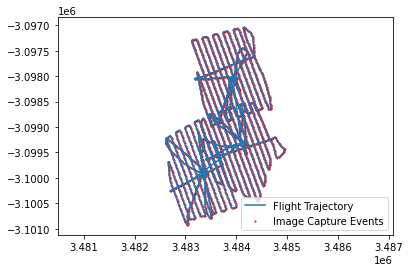

In [179]:
fig, ax = plt.subplots()
ax.plot(UTMTraj.Easting, UTMTraj.Northing, label='Flight Trajectory')
ax.scatter(East_interp, North_interp, c='r', s=1, label='Image Capture Events')
plt.axis('equal')
ax.legend()

In [180]:
# Make an image trajectory df
imgtime_df = it.assign(Northing=North_interp, 
                       Easting=East_interp,
                       Altitude=Alt_interp,
                       Site=proj.projstr,
                       Date=proj.date)
imgtime_df.head()

,GPSTime,Imagef,Northing,Easting,Altitude,Site,Date
0,367614.238,Flight1_cam1-000-000000-0,-3.099980e+06,3.483309e+06,265.506409,NkuluEP,2020-01-16
1,367617.308,Flight1_cam1-000-000001-0,-3.099997e+06,3.483292e+06,269.988831,NkuluEP,2020-01-16
2,367620.244,Flight1_cam1-000-000002-0,-3.100021e+06,3.483279e+06,274.606323,NkuluEP,2020-01-16
3,367623.180,Flight1_cam1-000-000003-0,-3.100047e+06,3.483277e+06,278.648834,NkuluEP,2020-01-16
4,367626.250,Flight1_cam1-000-000004-0,-3.100070e+06,3.483279e+06,281.370331,NkuluEP,2020-01-16


### Add day, month, year, and GTC time

In [181]:
# Convert gps time to Local time
# import datetime
from datetime import datetime, timedelta, timezone
import pytz

# offset is offset from GTCT time (SA is +2)
def convertGPSTimetoLocalTime(time, day, month, year, offset=2):

    # force to int for use in datetime 
    day = int(day)
    month = int(month)
    year = int(year)

    # Make datetime object of input GPStime
    dt = datetime(day=day, month=month, year=year, tzinfo=timezone.utc)

    # Start the time of that week (since GPS TOW counts seconds since the start of the week)
    # Subtract number of days  isoweekday() of base station date to count back to the beg. of week
    start_of_week = datetime(year = year,
                             day = day,
                             month = month) - timedelta(days=dt.isoweekday())

    # Use datetime's timedelta to add the GPS TOW seconds to the start of the week datetime
    curr_dt = start_of_week + timedelta(seconds=time)
    
    # Convert to local time using offset from gtc
    curr_dt = curr_dt + timedelta(hours=2)

    # Set the current date and time! Easy.
    date = curr_dt.strftime("%Y-%m-%d")
    UTC = curr_dt.strftime("%H:%M:%S")
                             
    return curr_dt


# # Function for going backwards
# # where dt is a datetime object
# # and offset defines it's hourly offset from utc time
# def LocalTimetoGPSTime(dt, offset=2):

#     # Make datetime object of input time
#     # Subtract time offset here
#     dt = datetime(day=day, month=month, year=year, tzinfo=timezone.utc) - timedelta(hours=2)

#     # Start the time of that week (since GPS TOW counts seconds since the start of the week)
#     # Subtract number of days  isoweekday() of base station date to count back to the beg. of week
#     start_of_week = datetime(year = year,
#                              day = day,
#                              month = month) - timedelta(days=dt.isoweekday())

#     # Use datetime's timedelta to add the GPS TOW seconds to the start of the week datetime
#     curr_dt = start_of_week + timedelta(seconds=time)
    
#     # Convert to local time using offset from gtc
#     curr_dt = curr_dt + timedelta(hours=2)

#     # Set the current date and time! Easy.
#     date = curr_dt.strftime("%Y-%m-%d")
#     UTC = curr_dt.strftime("%H:%M:%S")
                             
#     return curr_dt


In [262]:
# Compute time of each 
d = proj.date.split('-')[2]
m = proj.date.split('-')[1]
y = proj.date.split('-')[0]
imgtime_df['DateTime'] = imgtime_df.GPSTime.apply(lambda t: convertGPSTimetoLocalTime(t, day=d, month=m, year=y))
imgtime_df['Time'] = imgtime_df.GPSTime.apply(lambda t: convertGPSTimetoLocalTime(t, day=d, month=m, year=y).strftime("%H:%M:%S"))

In [183]:
imgtime_df.head()
# repeat for other Thermal landscapes sites

,GPSTime,Imagef,Northing,Easting,Altitude,Site,Date,Time
0,367614.238,Flight1_cam1-000-000000-0,-3.099980e+06,3.483309e+06,265.506409,NkuluEP,2020-01-16,08:06:54
1,367617.308,Flight1_cam1-000-000001-0,-3.099997e+06,3.483292e+06,269.988831,NkuluEP,2020-01-16,08:06:57
2,367620.244,Flight1_cam1-000-000002-0,-3.100021e+06,3.483279e+06,274.606323,NkuluEP,2020-01-16,08:07:00
3,367623.180,Flight1_cam1-000-000003-0,-3.100047e+06,3.483277e+06,278.648834,NkuluEP,2020-01-16,08:07:03
4,367626.250,Flight1_cam1-000-000004-0,-3.100070e+06,3.483279e+06,281.370331,NkuluEP,2020-01-16,08:07:06


In [271]:
# Last - Connect with Weather Data
from gps_time import GPSTime

# Read in Weather data
f = Path('./data/in/WeatherData_ThermalLandscapes_curated.csv')

weatherdf = pd.read_csv(f)
# weatherdf.head()

# Convert weatherdf times to gps times 
# So that you can interpolate temp/RH values
# apply to dataframe
weatherdf['DateTime'] = weatherdf.apply(lambda x: datetime.strptime(f'{x.Date} {x.Time}',
                                                                    '%m/%d/%Y %H:%M'),
                                                                    axis=1)

weatherdf['GPSTime'] = weatherdf.DateTime.apply(lambda x: GPSTime.from_datetime(x).time_of_week)

# Rewrite the time column to be consistent with the imagetime_df Times, 
# so that they plot on top of each other in matplotlib
weatherdf['Time'] = weatherdf.DateTime.apply(lambda x: x.strftime("%H:%M:%S"))

# Add in weather information by interpolating
RH_interp = []
Temp_interp = []

for t in imgtime_df.GPSTime:
    
    # Index of time in trajectory closest to the image capture
    idx = np.argmin(np.abs(weatherdf.GPSTime - t))
    
    # Get the interpolated weather values
    RH_interp.append(np.interp(t,
                               weatherdf.GPSTime[(idx-3):(idx+3)],
                               weatherdf.Rhum_Perc[(idx-3):(idx+3)]))
    
    Temp_interp.append(np.interp(t,
                                 weatherdf.GPSTime[(idx-3):(idx+3)],
                                 weatherdf.Tdry_C[(idx-3):(idx+3)])) 
    
   # Temp_interp.append(np.interp(t,
                             # weatherdf.GPSTime[(idx-2):(idx+2)],
                             # weatherdf.Tdry_C[(idx-2):(idx+2)])) 

imgtime_df['RH'] = RH_interp
imgtime_df['AirTemp'] = Temp_interp
# weatherdf.head()
imgtime_df.head()

,GPSTime,Imagef,Northing,Easting,Altitude,Site,Date,Time,RH,AirTemp,DateTime
0,367614.238,Flight1_cam1-000-000000-0,-3.099980e+06,3.483309e+06,265.506409,NkuluEP,2020-01-16,08:06:54,91.762749,22.583477,2020-01-16 08:06:54.238
1,367617.308,Flight1_cam1-000-000001-0,-3.099997e+06,3.483292e+06,269.988831,NkuluEP,2020-01-16,08:06:57,91.759508,22.584466,2020-01-16 08:06:57.308
2,367620.244,Flight1_cam1-000-000002-0,-3.100021e+06,3.483279e+06,274.606323,NkuluEP,2020-01-16,08:07:00,91.756409,22.585412,2020-01-16 08:07:00.244
3,367623.180,Flight1_cam1-000-000003-0,-3.100047e+06,3.483277e+06,278.648834,NkuluEP,2020-01-16,08:07:03,91.753310,22.586358,2020-01-16 08:07:03.180
4,367626.250,Flight1_cam1-000-000004-0,-3.100070e+06,3.483279e+06,281.370331,NkuluEP,2020-01-16,08:07:06,91.750069,22.587347,2020-01-16 08:07:06.250


In [269]:
# Subset to current project site (note: site names might be slightly different/mispelled)
weatherdf_nkuhlu = weatherdf.loc[weatherdf.Site == 'Nkhulu']
weatherdf_nkuhlu

,Station,Date,Time,Tdry_C,Max_Tdry_C,Min_Tdry_C,Rhum_Perc,Dewpoint_C,Rain_mm,WSpd_kmh,...,Srad_mJ,Sun_Hours,Eto_mm,Absolute_RH_gm3,Specific_RH_gkg,Battery,Data_type,Site,DateTime,GPSTime
0,Skukuza,1/16/2020,03:00:00,22.73,0.0,NaN,95.3,21.94,0.0,0.18,...,3.9,1.0,0.74,19.37,18.26,4.12,Logger,Nkhulu,2020-01-16 03:00:00,356400.0
1,Skukuza,1/16/2020,04:00:00,23.74,0.0,NaN,91.0,22.18,0.0,1.44,...,3.9,1.0,0.73,19.64,18.56,4.12,Logger,Nkhulu,2020-01-16 04:00:00,360000.0
2,Skukuza,1/16/2020,05:00:00,24.03,0.0,NaN,89.1,22.12,0.0,0.65,...,3.9,1.0,0.75,19.57,18.50,4.12,Logger,Nkhulu,2020-01-16 05:00:00,363600.0
3,Skukuza,1/16/2020,06:00:00,24.02,0.0,NaN,88.1,21.93,0.0,1.48,...,3.9,1.0,0.74,19.36,18.29,4.12,Logger,Nkhulu,2020-01-16 06:00:00,367200.0
4,Skukuza,1/16/2020,07:00:00,23.64,0.0,NaN,88.1,21.55,0.0,1.69,...,3.9,1.0,0.73,18.94,17.86,4.12,Logger,Nkhulu,2020-01-16 07:00:00,370800.0
5,Skukuza,1/16/2020,08:00:00,22.45,0.0,NaN,92.2,21.12,0.0,0.50,...,3.9,1.0,0.73,18.47,17.36,4.12,Logger,Nkhulu,2020-01-16 08:00:00,374400.0
6,Skukuza,1/16/2020,09:00:00,23.61,0.0,NaN,88.4,21.58,0.0,3.17,...,3.9,1.0,0.71,18.97,17.89,4.12,Logger,Nkhulu,2020-01-16 09:00:00,378000.0
7,Skukuza,1/16/2020,10:00:00,26.59,0.0,NaN,75.4,21.88,0.0,4.39,...,3.9,1.0,0.74,19.30,18.32,4.13,Logger,Nkhulu,2020-01-16 10:00:00,381600.0
8,Skukuza,1/16/2020,11:00:00,28.59,0.0,NaN,65.8,21.56,0.0,4.39,...,3.9,1.0,0.77,18.95,18.03,4.13,Logger,Nkhulu,2020-01-16 11:00:00,385200.0
9,Skukuza,1/16/2020,12:00:00,29.57,0.0,NaN,60.2,21.03,0.0,4.86,...,3.9,1.0,0.79,18.38,17.50,4.13,Logger,Nkhulu,2020-01-16 12:00:00,388800.0


/tmp/ipykernel_18499/2450901493.py:11: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(),rotation=90)
/tmp/ipykernel_18499/2450901493.py:24: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(),rotation=90)


<AxesSubplot:xlabel='DateTime', ylabel='Rel. Humidity [%]'>

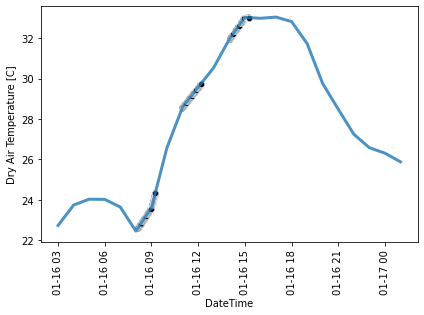

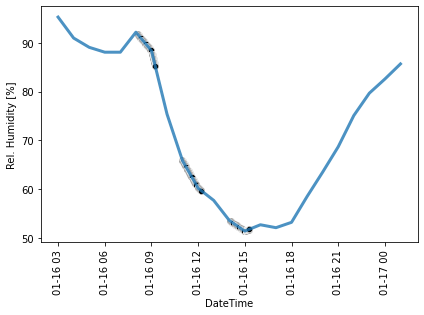

In [274]:
import seaborn as sns

fig, ax = plt.subplots()
sns.lineplot(data=weatherdf_nkuhlu,
             x='DateTime', y='Tdry_C',
             lw=3, alpha=0.8, ax=ax)

ax.set_ylabel('Dry Air Temperature [C]')
fig.tight_layout()
# plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
ax.set_xticklabels(ax.get_xticklabels(),rotation=90)

sns.scatterplot(data = imgtime_df, x='DateTime', y='AirTemp', color='k')


fig, ax = plt.subplots()
sns.lineplot(data=weatherdf_nkuhlu,
             x='DateTime', y='Rhum_Perc',
             lw=3, alpha=0.8, ax=ax)

ax.set_ylabel('Rel. Humidity [%]')
fig.tight_layout()
# plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
ax.set_xticklabels(ax.get_xticklabels(),rotation=90)

sns.scatterplot(data = imgtime_df, x='DateTime', y='RH', color='k')

In [276]:
# Save it! 
# ALl good. Now you just need to subset the important images,
# and add temp and humidity values to the model
imgtime_df.to_csv(f'./data/in/ImageTrajectories/{proj.projstr}_ImageTrajectory_withWeather.csv')
weatherdf.to_csv(f'./data/in/WeatherDataFrame_DateTime.csv')

### TESTING below

In [ ]:

# Testing: 
# Convert weatherdf times to gps times 
# why? so that you can interpolate temp/RH values, and np.interp only likes to take floats!
# see: https://stackoverflow.com/questions/27926669/how-do-you-interpolate-from-an-array-containing-datetime-objects

# Use the GPSTime module here:
# it appears to give the same results as your functions
# # See: https://www.digitalocean.com/community/tutorials/python-string-to-datetime-strptime for format
# dt_weather = datetime.strptime(f'{weatherdf.Date.loc[0]} {weatherdf.Time.loc[0]}',
#                                '%m/%d/%Y %H:%M')
# # Get GPS Seconds
# GPS_s = GPSTime.from_datetime(dt_weather).time_of_week

# def makeGPSTimefromDF():


In [184]:
# TESTING

d = proj.date.split('-')[2]
m = proj.date.split('-')[1]
y = proj.date.split('-')[0]
dt = convertGPSTimetoUTC(UTMTraj.GPSTime.min(),
                                    day=d, month=m, year=y)

# imgtime_df.GPSTime.loc[0]

# Convert to local time
# Super confusing, but you have to make an object with pytz
# which has all the country time zone codes
# South africa's string time zone can be found here:
# pytz.country_timezones['ZA']
# Then you take the string time zone and make an object
# then you use that object in astimezone() function in datetime
# weird, but it works\
# https://stackoverflow.com/questions/4563272/how-to-convert-a-utc-datetime-to-a-local-datetime-using-only-standard-library
# SCRAPPED the above... SA is 2 hours ahead of UTC, so just add 2 hours

# Convert to local time 
dt_local = dt + timedelta(hours=2)
dt_local.strftime("%Y-%m-%d %H:%M:%S")

# Checking
# from gps_time import GPSTime

# gpst = GPSTime.from_datetime(dt)

# # dt.strftime("%Y-%m-%d %H:%M:%S"), gpst.to_datetime().strftime("%Y-%m-%d %H:%M:%S")
# # They're both the same, so... that means they're correct?
# gpst, UTMTraj.GPSTime.min()

'2020-01-16 07:56:25'